# Stat 220, Unit 2 Homework: A Map of Models

`campus_cafe.csv` is 700 days at a campus coffee shop: `temp_f`, `exam_week`,
`promo`, `foot_traffic`, `drinks_sold`, `revenue`, and `sold_out`.


In [10]:
%pip install scikit-learn

  Using cached scikit_learn-1.9.1-cp314-cp314-macosx_12_0_arm64.whl.metadata (9.3 kB)
  Using cached joblib-1.6.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
Using cached scikit_learn-1.9.1-cp314-cp314-macosx_12_0_arm64.whl (8.3 MB)
Using cached joblib-1.6.0-py3-none-any.whl (306 kB)
Using cached cloudpickle-3.1.2-py3-none-any.whl (22 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-learn] [scikit-learn]

[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [11]:
import pandas as pd, numpy as np
import statsmodels.api as sm, statsmodels.formula.api as smf
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression

cafe = pd.read_csv("https://drbob-richardson.github.io/stat220/F2026/data/campus_cafe.csv")
cafe.head()

,day_of_week,temp_f,exam_week,promo,foot_traffic,drinks_sold,revenue,sold_out
0,Fri,64.1,0,1,908,20,73.00,1
1,Mon,40.1,0,0,877,21,79.75,0
2,Mon,38.0,1,0,1243,27,137.08,1
3,Thu,50.9,0,0,1442,35,140.86,0
4,Tue,68.6,0,0,1060,23,104.40,0


In [ ]:
%pip install matpl

  Using cached matplotlib-3.11.2-cp314-cp314-macosx_11_0_arm64.whl.metadata (80 kB)
  Using cached contourpy-1.4.0-cp314-cp314-macosx_11_0_arm64.whl.metadata (3.8 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.5.1-cp314-cp314-macosx_11_0_arm64.whl.metadata (5.2 kB)
  Using cached numpy-2.5.3-cp314-cp314-macosx_14_0_arm64.whl.metadata (6.6 kB)
  Using cached pillow-12.3.0-cp314-cp314-macosx_11_0_arm64.whl.metadata (9.1 kB)
  Using cached pyparsing-3.3.3-py3-none-any.whl.metadata (5.9 kB)
Using cached matplotlib-3.11.2-cp314-cp314-macosx_11_0_arm64.whl (9.3 MB)
Using cached contourpy-1.4.0-cp314-cp314-macosx_11_0_arm64.whl (283 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 26.6 MB/s  0:00:00
Using cached kiwisolver-1.5.1-cp314-cp314-macosx_11_0_arm64.whl (64 kB)
Using cached numpy-2.5.3-cp314-cp314-macosx_14_0_arm64.whl (5.4 MB)
Using cached pillow-12.3.0-cp314-cp314-macosx_

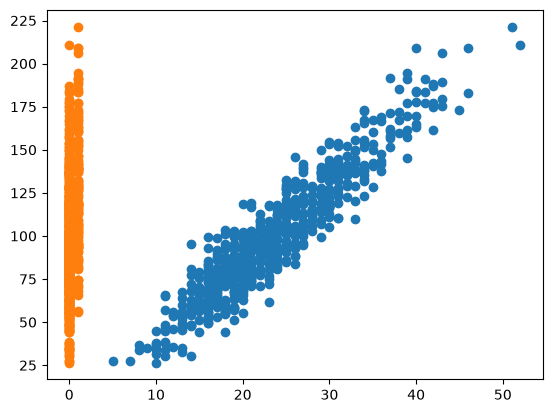

In [15]:
import matplotlib.pyplot as plt
plt.scatter(cafe['drinks_sold'], cafe['revenue'])
plt.scatter(cafe['exam_week'], cafe['revenue'])

**Problem 1.** *Reading a situation.* No computer.

Part a. The owner wants to know how many drinks to prepare tomorrow, given the forecast temperature. What type is `y` here, and which model family would you name?

_Your answer:_



y would be a whole number, a count. Because the owner wants to know how many drinks to prepare tomorrow, that is a prediction, so I will use a prediction model. 

Part b. The owner wants to know whether running a promotion actually raises revenue, since she is deciding whether to keep doing it. What type is `y`, which family, and what makes this a different job from part a?

_Your answer:_



y would be a continuous number. It represents the change in revenue based on promotion. I would use a probability model because the owner wants to know the significance of promotions in revenue. This is different than a prediction model (part a) because it's not asking for a specific value or prediction, but a probability. 

Part c. The owner wants the chance they run out of an item on a given day. What type is `y`, and which family?

_Your answer:_



y would be a continuous number from the probability models family, because it's asking for a chance (probability) of something running out.

Part d. A classmate says to just use a random forest for all three. A forest would run on all three without complaining. Say which of the three you would refuse to use it for, and why.

_Your answer:_



A random forest is a prediction model, however part b and c are probability model problems. Though random forest would work for these problems, use specific probability models would give a more precise and accurate result to answer the owner's questions, which is why I would refuse to use random forest for all three. A random forest could be a good fit for part a.

**Problem 2.** *What happens if you ignore the type of `y`.*

Part a. `sold_out` is a yes/no column. Describe what the linear model produced that the logistic model did not, and say why that is a problem.

In [12]:
# the right model for a yes/no outcome
p_ok = smf.logit("sold_out ~ drinks_sold", data=cafe).fit(disp=0).predict()

# the same outcome, forced into a linear model
p_bad = smf.ols("sold_out ~ drinks_sold", data=cafe).fit().predict()

print(f"logistic gives values from {p_ok.min():.3f} to {p_ok.max():.3f}")
print(f"linear   gives values from {p_bad.min():.2f} to {p_bad.max():.2f}")
print("linear values that are not possible probabilities:",
      int(((p_bad < 0) | (p_bad > 1)).sum()), "out of", len(p_bad))

logistic gives values from 0.026 to 0.971
linear   gives values from -0.19 to 1.15
linear values that are not possible probabilities: 25 out of 700


_Your answer:_



Linear values produced values below 0 and above 1. Logistic regression only produced values between 0 and 1. Because sold_out expects a yes/no output, it's a binary classification. To classify it, the probability output z should be between 0 and 1, if z < 0.5 the results is 0 (no), if z > 0.5 then the result is 1 (yes). This type of classification is not possible with the linear values produced so can't be classified correctly. 

Part b. `drinks_sold` is a count. Name the probability model you would use for it, and say in one sentence what would go wrong with an ordinary linear model there.

_Your answer:_



I would use Poisson Regression because it is meant for count distributions. If I used an ordinary linear model, there would be continuous numbers. However, because a count variable only expects whole numbers, having a continuous number would be hard to interpret. 

**Problem 3.** *What a model can and cannot hand back.*

Part a. List the quantities the forest could not produce, and explain why not. Your answer should use the word distribution.

In [13]:
X = cafe[["drinks_sold", "exam_week", "promo", "temp_f"]]
reg = LinearRegression().fit(X, cafe["revenue"])
forest = RandomForestRegressor(n_estimators=300, random_state=0).fit(X, cafe["revenue"])
sm_reg = smf.ols("revenue ~ drinks_sold + exam_week + promo + temp_f", data=cafe).fit()

for name, model in [("regression", sm_reg), ("forest", forest)]:
    have = [a for a in ["pvalues", "conf_int", "aic"] if hasattr(model, a)]
    print(f"{name:<12} can give you: {have if have else 'none of them'}")

regression   can give you: ['pvalues', 'conf_int', 'aic']
forest       can give you: none of them


_Your answer:_



Random Forests cannot produce pvalues, confidence intervals, and aic because regression is a probability model, and forest is not. These values are only produced by probability models. 

Part b. Go back to the three jobs in Problem 1. Which one of them could a forest not do at all, given what you just saw?

_Your answer:_



I believe that a random forest would not be able to do problem 1.b. That is because to determine whether promotions have a significance in revenue, a p-value is necessary, which random forests do not produce. This means that the output for a random forest for this problem would not answer the owner's question. 

**Problem 4.** *Is model A better than model B?*

Part a. These three models are compared by AIC. Say which one you would keep, and what it means that one of the additions made AIC go up.

In [14]:
for f in ["revenue ~ drinks_sold",
          "revenue ~ drinks_sold + exam_week",
          "revenue ~ drinks_sold + exam_week + promo"]:
    print(f"{f:<48} AIC = {smf.ols(f, data=cafe).fit().aic:8.1f}")

revenue ~ drinks_sold                            AIC =   5492.8
revenue ~ drinks_sold + exam_week                AIC =   5442.6
revenue ~ drinks_sold + exam_week + promo        AIC =   5444.3


_Your answer:_



I would pick the second model (revenue ~ drinks_sold + exam_week) because it has the lowest AIC. AIC is a metric to compare models by how well they fit the data and how complex they are. If adding a feature makes AIC increase, the accuracy improvement was not enough to justify the added complexity.

Part b. Say which model you would ship, and whether the result surprises you.

In [15]:
folds = KFold(5, shuffle=True, random_state=0)   # one fold object, used for both
for name, mod in [("regression", LinearRegression()),
                  ("forest", RandomForestRegressor(n_estimators=300, random_state=0))]:
    mse = -cross_val_score(mod, X, cafe["revenue"], cv=folds,
                           scoring="neg_mean_squared_error").mean()
    print(f"  {name:<12} cross-validated MSE {mse:7.1f}   RMSE {np.sqrt(mse):5.1f} dollars")

  regression   cross-validated MSE   140.2   RMSE  11.8 dollars
  forest       cross-validated MSE   171.9   RMSE  13.1 dollars


_Your answer:_



I would pick Regression because it has a smaller MSE and RMSE. This does not surprise me because revenue has a linear relationship with attributes like drinks_sold, which fit the linear regression model best. 

Part c. You could compare the three models in part a with AIC, but you could not use AIC for the comparison in part b. Explain why in two sentences.

_Your answer:_



AIC is meant for probability models, which Random Forest is not. To compare Linear Regression and Random Forests equaly another metric had to be used, which is MSE/RMSE. 

**Problem 5.** *Putting it together.* No computer.

Part a. The owner reads that a forest predicted revenue almost as well as the regression, and asks whether she should use the forest to decide about promotions. Answer her in three or four sentences.

_Your answer:_



To determine whether promotions have a significance with revenues, certain stastical values, like a p-value, are necessary. Though Random Forests predict well the revenue, random forests do not produce statistical values like p-values, so the results of a forest is not enough to determine significance of promotions to revenue. Linear Regressions do produce p-values and other statistical measurments (confidence intervals, etc.) so it can answer the owner's question best. For this reason, a linear regression would be best to answer the owner's question.